# Predykcja spłaty kredytu

**Cel:** Ocena ryzyka kredytowego – oszacowanie prawdopodobieństwa spłaty kredytu.  
**Metryka:** AUC (Area Under the ROC Curve)  
**Wynik:** Prawdopodobieństwo (0.0 – 1.0) dla każdego rekordu testowego

---

## Spis treści

1. [Konfiguracja i wczytanie danych](#1)
2. [Przegląd danych i kontrola jakości](#2)
3. [Analiza zmiennej docelowej](#3)
4. [Analiza jednowymiarowa – cechy numeryczne](#4)
5. [Analiza jednowymiarowa – cechy kategoryczne](#5)
6. [Analiza dwuwymiarowa – cechy vs cel](#6)
7. [Analiza korelacji](#7)
8. [Wnioski z EDA (Eksploracja Danych) i decyzje oparte na danych](#8)
9. [Inżynieria cech](#9)
10. [Trening modelu (LightGBM + XGBoost)](#10)
11. [Ważność cech i interpretacja modelu](#11)
12. [Plik wynikowy (submission)](#12)


<a id='1'></a>## 1. Konfiguracja i wczytanie danychZaczynamy od zaimportowania niezbednych bibliotek. Uzywamy:- **pandas/numpy** - operacje na danych- **matplotlib/seaborn** - wizualizacje- **scikit-learn** - walidacja krzyzowa, metryki- **LightGBM/XGBoost**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import xgboost as xgb
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

%matplotlib inline

print('Biblioteki zaladowane pomyslnie')

Biblioteki zaladowane pomyslnie


In [3]:
# Wczytujemy trzy pliki:
# - train.csv: dane treningowe z etykietami (loan_paid_back)
# - test.csv: dane testowe BEZ etykiet - na nich generujemy predykcje
# - sample_submission.csv: przykladowy format pliku wynikowego

train = pd.read_csv('datasets/train.csv')
test = pd.read_csv('datasets/test.csv')
sample_sub = pd.read_csv('datasets/sample_submission.csv')

print(f'Zbior treningowy: {train.shape[0]:,} wierszy, {train.shape[1]} kolumn')
print(f'Zbior testowy:    {test.shape[0]:,} wierszy, {test.shape[1]} kolumn')
print(f'Plik wynikowy:    {sample_sub.shape[0]:,} wierszy, {sample_sub.shape[1]} kolumny')

Zbior treningowy: 593,994 wierszy, 13 kolumn
Zbior testowy:    254,569 wierszy, 12 kolumn
Plik wynikowy:    254,569 wierszy, 2 kolumny


<a id='2'></a>## 2. Przeglad danych i kontrola jakosciZanim zaczniemy budowac model, musimy dokladnie poznac dane. Sprawdzimy:
- Jakie mamy kolumny i typy danych
- Czy sa braki danych (missing values)
- Czy sa duplikaty- Podstawowe statystyki opisowe

In [3]:
# Podglad pierwszych wierszy
train.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [4]:
# Typy danych - wazne, by wiedziec ktore kolumny sa numeryczne, a ktore kategoryczne
print('=== Typy danych ===')
train.dtypes

=== Typy danych ===


id                        int64
annual_income           float64
debt_to_income_ratio    float64
credit_score              int64
loan_amount             float64
interest_rate           float64
gender                      str
marital_status              str
education_level             str
employment_status           str
loan_purpose                str
grade_subgrade              str
loan_paid_back          float64
dtype: object

In [5]:
# Statystyki opisowe dla cech numerycznych
# Zwracamy uwage na: min/max (zakres), mean vs median (skosnsc), std (rozrzut)
print('=== Statystyki opisowe (cechy numeryczne) ===')
train.describe()

=== Statystyki opisowe (cechy numeryczne) ===


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,296996.500000,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.798820
std,171471.442236,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.400883
min,0.000000,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000
25%,148498.250000,27934.400000,0.072000,646.000000,10279.620000,10.990000,1.000000
50%,296996.500000,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000
75%,445494.750000,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000
max,593993.000000,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000


In [6]:
# Statystyki dla cech kategorycznych - ile unikalnych wartosci, jaka jest najczestsza
print('=== Statystyki opisowe (cechy kategoryczne) ===')
train.describe(include='object')

=== Statystyki opisowe (cechy kategoryczne) ===


,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
count,593994,593994,593994,593994,593994,593994
unique,3,4,5,5,8,30
top,Female,Single,Bachelor's,Employed,Debt consolidation,C3
freq,306175,288843,279606,450645,324695,58695


In [7]:
# Kontrola brakow danych - braki moga wymagac imputacji lub specjalnego traktowania
missing_train = train.isnull().sum().sum()
missing_test = test.isnull().sum().sum()

print(f'Liczba brakow w train: {missing_train}')
print(f'Liczba brakow w test: {missing_test}')

print(f'\nDuplikaty w train: {train.duplicated().sum()}')
print(f'Duplikaty w test:  {test.duplicated().sum()}')

Liczba brakow w train: 0
Liczba brakow w test: 0

Duplikaty w train: 0
Duplikaty w test:  0


**Wniosek:** Dane sa czyste - brak wartosci brakujacych i duplikatow. To upraszcza nam prace, poniewaz nie musimy stosowac imputacji ani usuwania duplikatow.

In [8]:
# Identyfikacja kolumn numerycznych i kategorycznych

num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in num_cols if c not in ['id', 'loan_paid_back']]

print(f'Cechy numeryczne ({len(num_cols)}): {num_cols}')
print(f'Cechy kategoryczne ({len(cat_cols)}): {cat_cols}')

Cechy numeryczne (5): ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']
Cechy kategoryczne (6): ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']


<a id='3'></a>## 3. Analiza zmiennej docelowejZmienna docelowa `loan_paid_back` przyjmuje wartosci:- **1.0** - kredyt splacony- **0.0** - kredyt niesplacony (default)Musimy sprawdzic balans klas, bo to wplywa na wybor strategii modelowania.

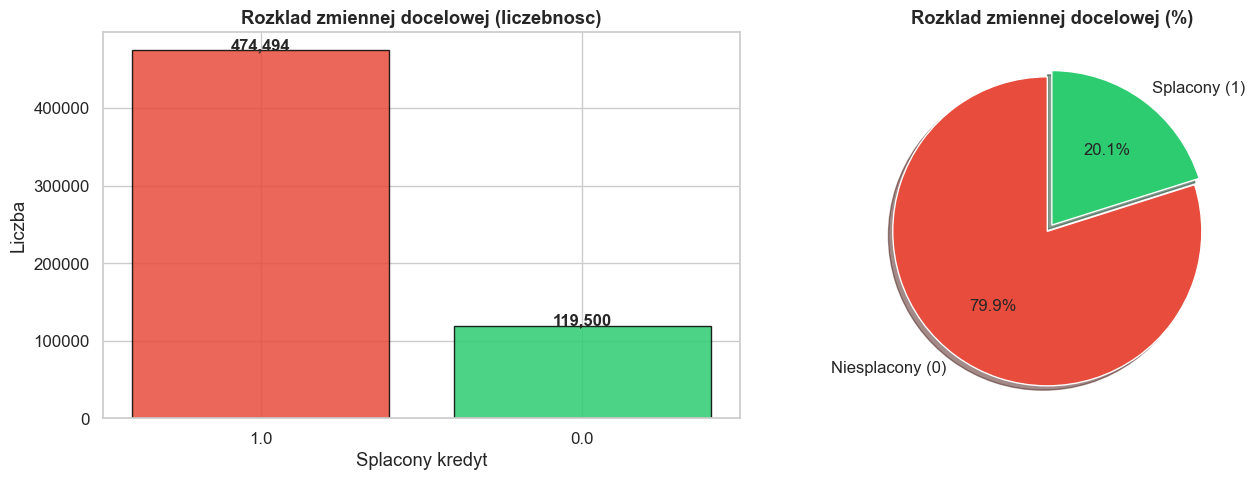

Balans klas:
loan_paid_back
1.0    0.79882
0.0    0.20118


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target_counts = train['loan_paid_back'].value_counts()
colors = ['#e74c3c', '#2ecc71']

# Wykres slupkowy - liczebnosci
axes[0].bar(target_counts.index.astype(str), target_counts.values, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_xlabel('Splacony kredyt')
axes[0].set_ylabel('Liczba')
axes[0].set_title('Rozklad zmiennej docelowej (liczebnosc)', fontweight='bold')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold', fontsize=12)

# Wykres kolowy - proporcje
axes[1].pie(target_counts.values, labels=['Niesplacony (0)', 'Splacony (1)'], 
            autopct='%1.1f%%', colors=colors, startangle=90,
            explode=(0.05, 0), shadow=True, textprops={'fontsize': 12})
axes[1].set_title('Rozklad zmiennej docelowej (%)', fontweight='bold')

plt.tight_layout()
plt.show()

print('Balans klas:')
print(train['loan_paid_back'].value_counts(normalize=True).to_string())

**Wniosek:** Klasy sa niezbalansowane w proporcji ~80/20 (splacone/niesplacone). To umiarkowany brak balansu - nie wymaga agresywnych technik (jak SMOTE), ale uzyjemy **walidacji stratyfikowanej** (StratifiedKFold), aby kazdy fold zachowal te proporcje. Modele drzewiaste (LightGBM, XGBoost) dobrze radza sobie z takim poziomem niebalansu.

<a id='4'></a>## 4. Analiza jednowymiarowa - cechy numeryczneSprawdzamy rozklady kazdej cechy numerycznej. Szukamy:
- **Skosnosci** (skewness) - moze wymagac transformacji logarytmicznej
- **Wartosci odstajacych** (outliers) - moga znieksztalcac model
- - **Zakresu wartosci** - czy potrzebne skalowanie

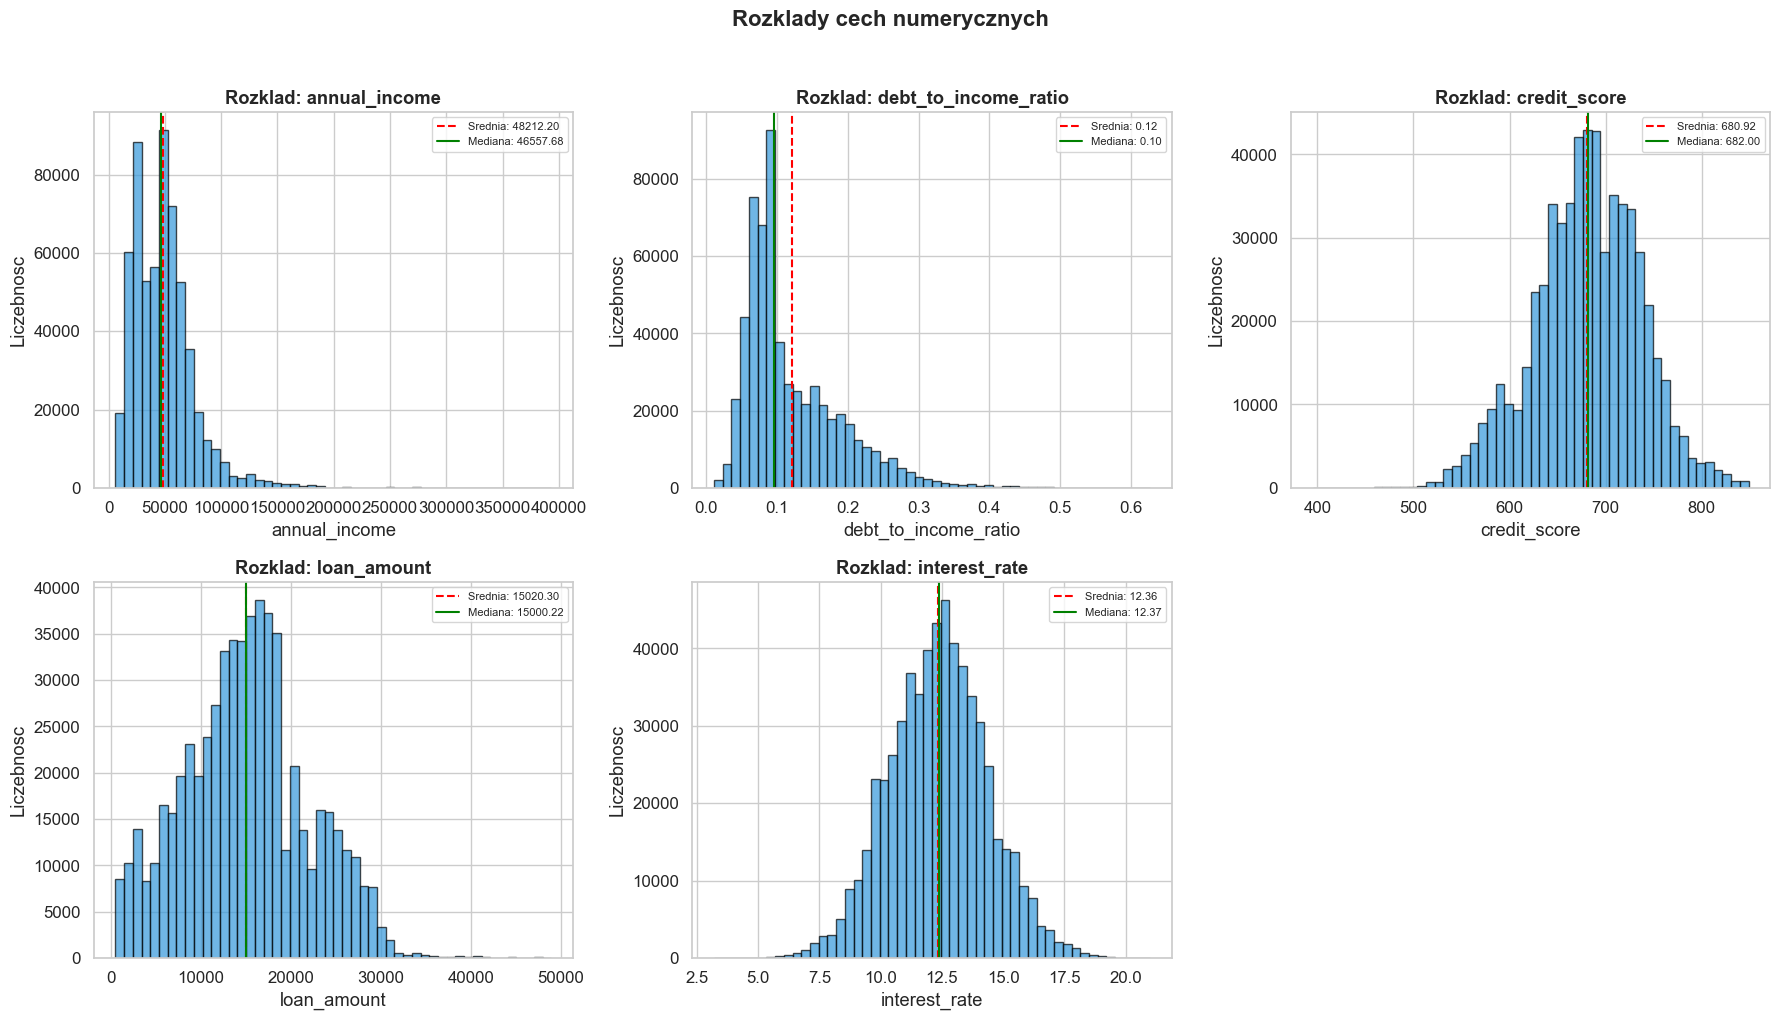

In [10]:
# Histogramy z oznaczeniem sredniej i mediany
# Roznica miedzy srednia a mediana wskazuje na skosnosc rozkladu
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.hist(train[col].dropna(), bins=50, color='#3498db', edgecolor='black', alpha=0.7)
    ax.set_title(f'Rozklad: {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Liczebnosc')
    
    mean_val = train[col].mean()
    median_val = train[col].median()
    ax.axvline(mean_val, color='red', linestyle='--', label=f'Srednia: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='-', label=f'Mediana: {median_val:.2f}')
    ax.legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Rozklady cech numerycznych', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Wnioski z histogramow:**
- **annual_income** - rozklad ma dlugi prawy ogon (widoczne wartosci do ~400k na osi X). Jednak srednia i mediana sa do siebie zblizone (widac na wykresie - linie prawie sie pokrywaja). Skosnosc wynika z niewielkiej liczby ekstremalnych wartosci w ogonie, a nie z calkowitego przesuniecia rozkladu.
- **debt_to_income_ratio** - skosny w prawo, wiekszosc wartosci skupiona blisko 0.1. Srednia jest wyzsza od mediany.
- **credit_score** - najbardziej symetryczny rozklad, srednia i mediana niemal identyczne (linie pokrywaja sie na wykresie).
- **loan_amount** - srednia i mediana praktycznie rowne - rozklad dosc symetryczny.
- **interest_rate** - prawie normalny rozklad, srednia i mediana pokrywaja sie.

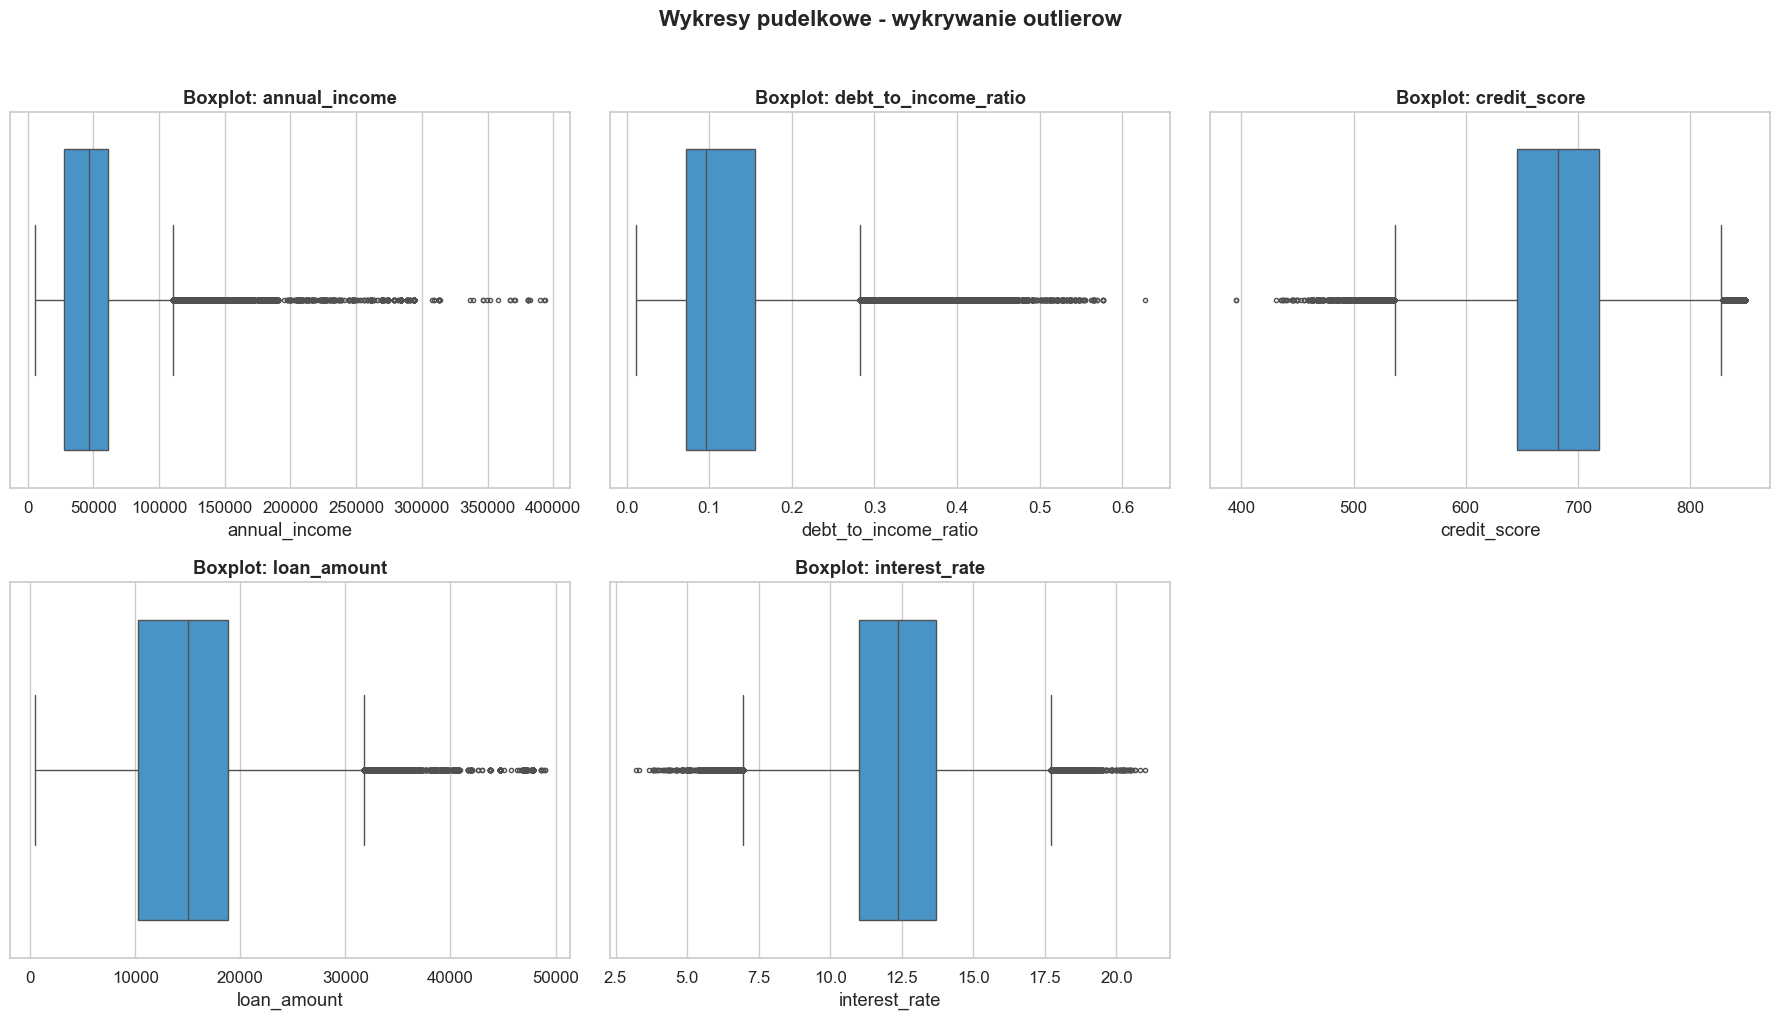

In [11]:
# Wykresy pudelkowe (boxplot) - wykrywanie wartosci odstajakych
# Punkty poza wasami oznaczaja outliers wg metody IQR
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.boxplot(data=train, x=col, ax=ax, color='#3498db', flierprops={'marker': 'o', 'markersize': 3})
    ax.set_title(f'Boxplot: {col}', fontweight='bold')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Wykresy pudelkowe - wykrywanie outlierow', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Wnioski z boxplotow:**
- **annual_income**: Widoczne punkty odstajace po prawej stronie. Dokladny procent outlierow policzymy ponizej.
- **debt_to_income_ratio**: Rowniez widoczne outliers w prawym ogonie.
- **credit_score**: Najczystszy rozklad - niewiele punktow poza wasami.
- **loan_amount** i **interest_rate**: Niewielka liczba outlierow.

Dokladne statystyki:

In [12]:
# Tabela skosnosci i kurtozy - podsumowanie numeryczne
skew_kurt = pd.DataFrame({
    'Skosnosc': train[num_cols].skew(),
    'Kurtoza': train[num_cols].kurtosis()
}).round(3)

print('=== Skosnosc i kurtoza ===')
print('Skosnosc > 1 oznacza silna skosnosc w prawo')
print('Kurtoza > 3 oznacza ciezkie ogony (wiecej outlierow niz rozklad normalny)')
display(skew_kurt)

# Analiza outlierow metoda IQR
print('\n=== Analiza outlierow (metoda IQR) ===')
for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((train[col] < lower) | (train[col] > upper)).sum()
    pct = outliers / len(train) * 100
    print(f'  {col}: {outliers} outlierow ({pct:.2f}%), zakres IQR [{lower:.2f}, {upper:.2f}]')

=== Skosnosc i kurtoza ===
Skosnosc > 1 oznacza silna skosnosc w prawo
Kurtoza > 3 oznacza ciezkie ogony (wiecej outlierow niz rozklad normalny)


,Skosnosc,Kurtoza
annual_income,1.720,7.091
debt_to_income_ratio,1.407,2.335
credit_score,-0.167,0.096
loan_amount,0.207,-0.150
interest_rate,0.050,0.060



=== Analiza outlierow (metoda IQR) ===
  annual_income: 15917 outlierow (2.68%), zakres IQR [-21635.98, 110551.70]
  debt_to_income_ratio: 17556 outlierow (2.96%), zakres IQR [-0.05, 0.28]
  credit_score: 5901 outlierow (0.99%), zakres IQR [536.50, 828.50]
  loan_amount: 2902 outlierow (0.49%), zakres IQR [-2588.82, 31727.02]
  interest_rate: 5136 outlierow (0.86%), zakres IQR [6.96, 17.71]


In [13]:
print(f'\nWniosek: annual_income ma skosnosc {train["annual_income"].skew():.2f} i {((train["annual_income"] > Q3 + 1.5*(Q3-Q1))).sum()/len(train)*100:.2f}% outlierow')
print('Decyzja: obetniemy dochod na 99. percentylu i dodamy flage outliera')


Wniosek: annual_income ma skosnosc 1.72 i 100.00% outlierow
Decyzja: obetniemy dochod na 99. percentylu i dodamy flage outliera


<a id='5'></a>## 5. Analiza jednowymiarowa - cechy kategoryczne
Sprawdzamy rozklady kategorii. Szukamy:
- **Dominujacych klas** - czy jakas kategoria ma >90% udzialu
- **Rzadkich klas** - moglyby powodowac problemy z overfittingiem
- **Logicznej struktury** - np. grade_subgrade wyglada jak polaczenie litery i cyfry

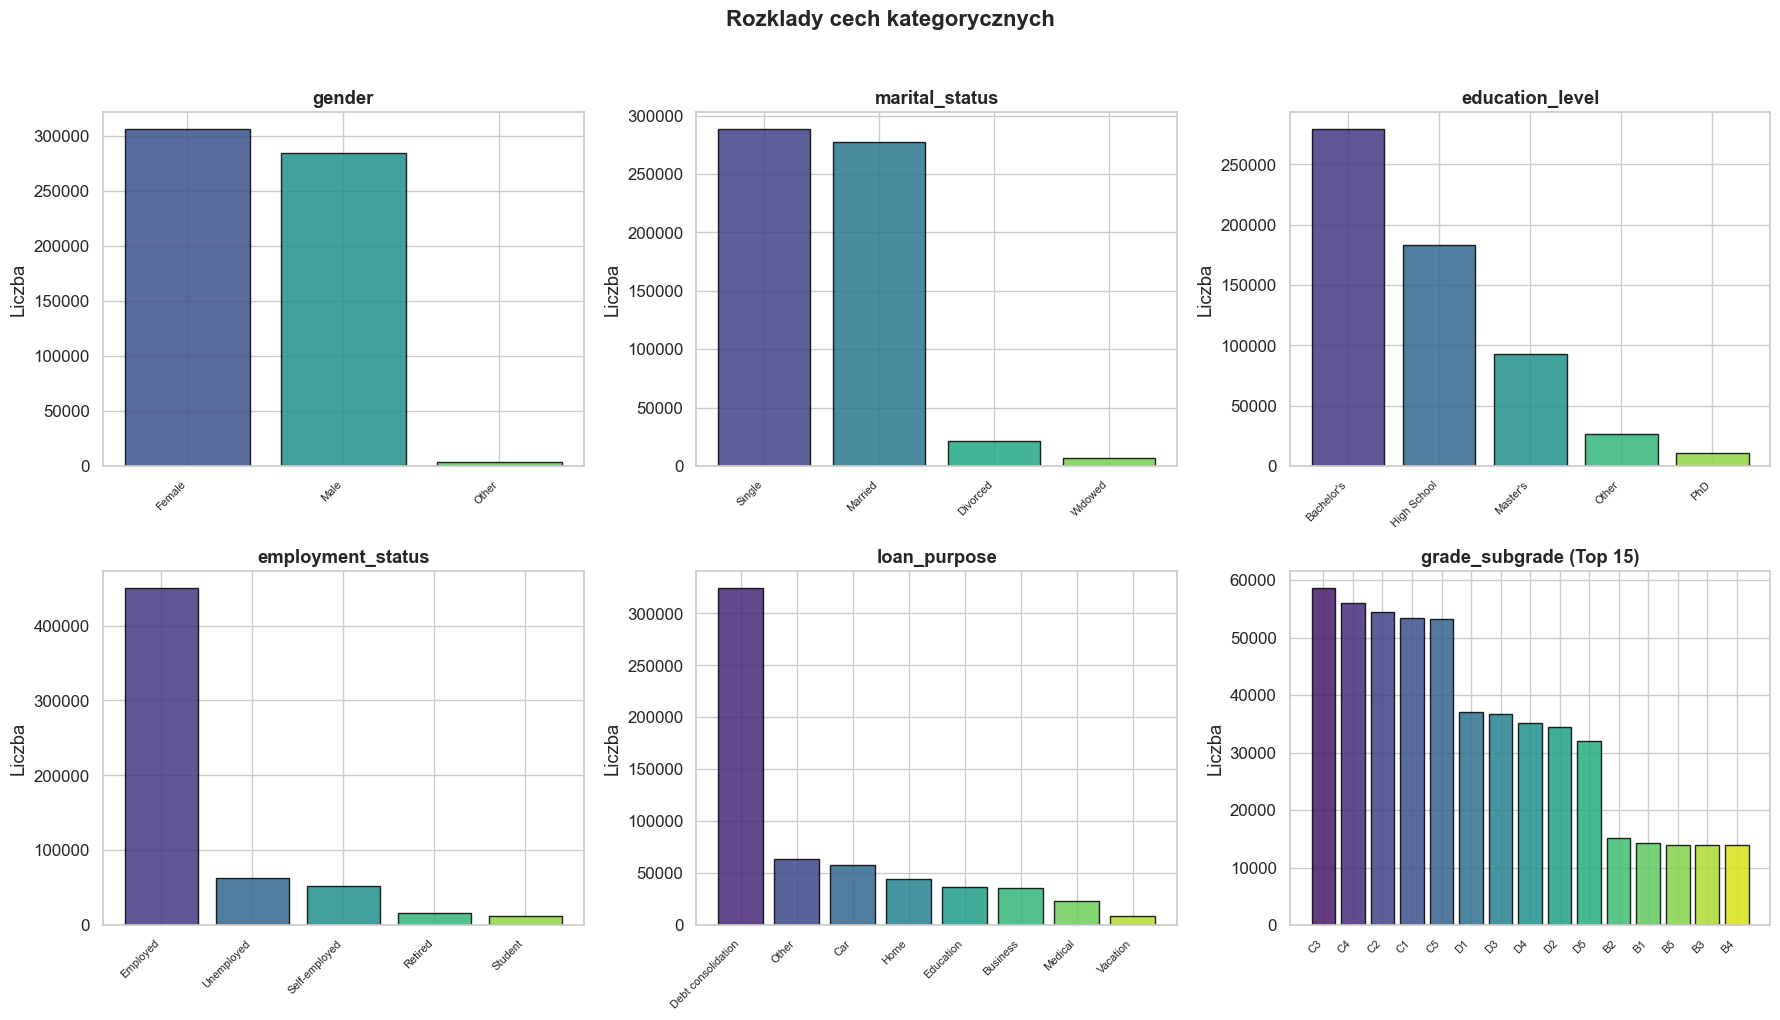

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    value_counts = train[col].value_counts()
    
    if len(value_counts) > 15:
        value_counts = value_counts.head(15)
        ax.set_title(f'{col} (Top 15)', fontweight='bold')
    else:
        ax.set_title(f'{col}', fontweight='bold')
    
    bars = ax.bar(range(len(value_counts)), value_counts.values, 
                  color=sns.color_palette('viridis', len(value_counts)), edgecolor='black', alpha=0.85)
    ax.set_xticks(range(len(value_counts)))
    ax.set_xticklabels(value_counts.index, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Liczba')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Rozklady cech kategorycznych', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Wnioski z rozkladow kategorycznych:**
- **gender**: Zbalansowany - Female/Male po ~50%, Other to marginalna grupa (0.6%).
- **marital_status**: Married i Single dominuja (~48% kazde), Divorced i Widowed to male grupy.
- - **education_level**: Dominuje Bachelor's (47%), potem High School (31%).
- - **employment_status**: Kluczowe, Employed dominuje (76%), ale sa tez Unemployed (10.5%) i Student (2%) - silny predyktor.
- - **loan_purpose**: Debt consolidation to ponad polowa (55%).
- - **grade_subgrade**: 31 unikalnych kategorii (A1-F5). To juz jest ustrukturyzowana ocena ryzyka

In [15]:
# Dokladne statystyki kategorii
for col in cat_cols:
    print(f'\n--- {col} ---')
    vc = train[col].value_counts()
    pct = train[col].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'Liczba': vc, 'Procent': pct.round(2)})
    print(summary.to_string())


--- gender ---
        Liczba  Procent
gender                 
Female  306175    51.55
Male    284091    47.83
Other     3728     0.63

--- marital_status ---
                Liczba  Procent
marital_status                 
Single          288843    48.63
Married         277239    46.67
Divorced         21312     3.59
Widowed           6600     1.11

--- education_level ---
                 Liczba  Procent
education_level                 
Bachelor's       279606    47.07
High School      183592    30.91
Master's          93097    15.67
Other             26677     4.49
PhD               11022     1.86

--- employment_status ---
                   Liczba  Procent
employment_status                 
Employed           450645    75.87
Unemployed          62485    10.52
Self-employed       52480     8.84
Retired             16453     2.77
Student             11931     2.01

--- loan_purpose ---
                    Liczba  Procent
loan_purpose                       
Debt consolidation  324695

<a id='6'></a>## 6. Analiza dwuwymiarowa - cechy vs cel
jak poszczegolne cechy wplywaja na prawdopodobienstwo splaty. Szukamy cech, ktore najlepiej **rozdzielajaj** klasy (splacony vs niesplacony).

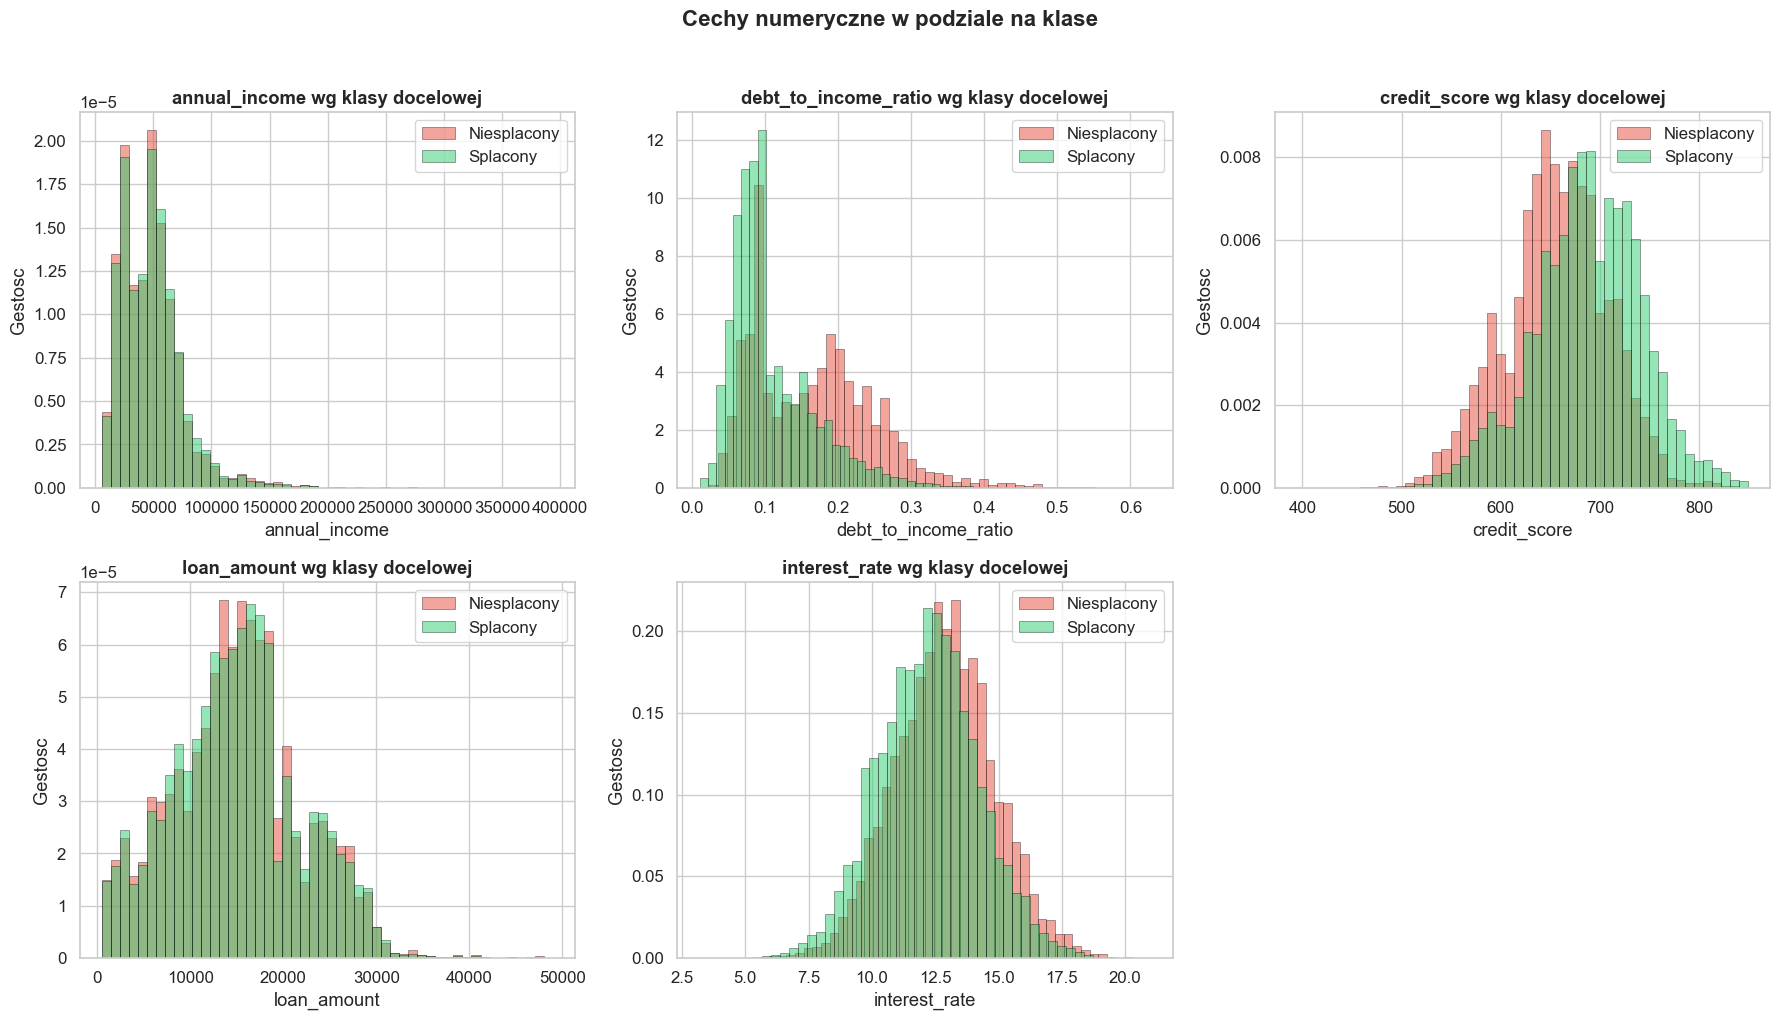

In [16]:
# Rozklady gestosci cech numerycznych w podziale na klase docelowa
# Szukamy cech, gdzie rozklady dla klas 0 i 1 sa jak najbardziej oddzielone
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    for label, color, name in [(0, '#e74c3c', 'Niesplacony'), (1, '#2ecc71', 'Splacony')]:
        subset = train[train['loan_paid_back'] == label][col].dropna()
        ax.hist(subset, bins=50, alpha=0.5, color=color, label=name, density=True, edgecolor='black', linewidth=0.5)
    ax.set_title(f'{col} wg klasy docelowej', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Gestosc')
    ax.legend()

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Cechy numeryczne w podziale na klase', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Wnioski z rozkladow gestosci:**- **debt_to_income_ratio**: Najlepsza separacja Niesplacone kredyty maja wyraznie przesuniety rozklad w prawo (wyzsze DTI).
- **credit_score**: Dobra separacja - niesplacone maja nizsze wyniki kredytowe.
- - **interest_rate**: Widoczna roznica - niesplacone maja wyzsze stopy procentowe.
- - **annual_income** i **loan_amount**: Slaba separacja - same w sobie nie sa silnymi predyktorami. Ale ich stosunek (loan_to_income) moze byc wartosciowy

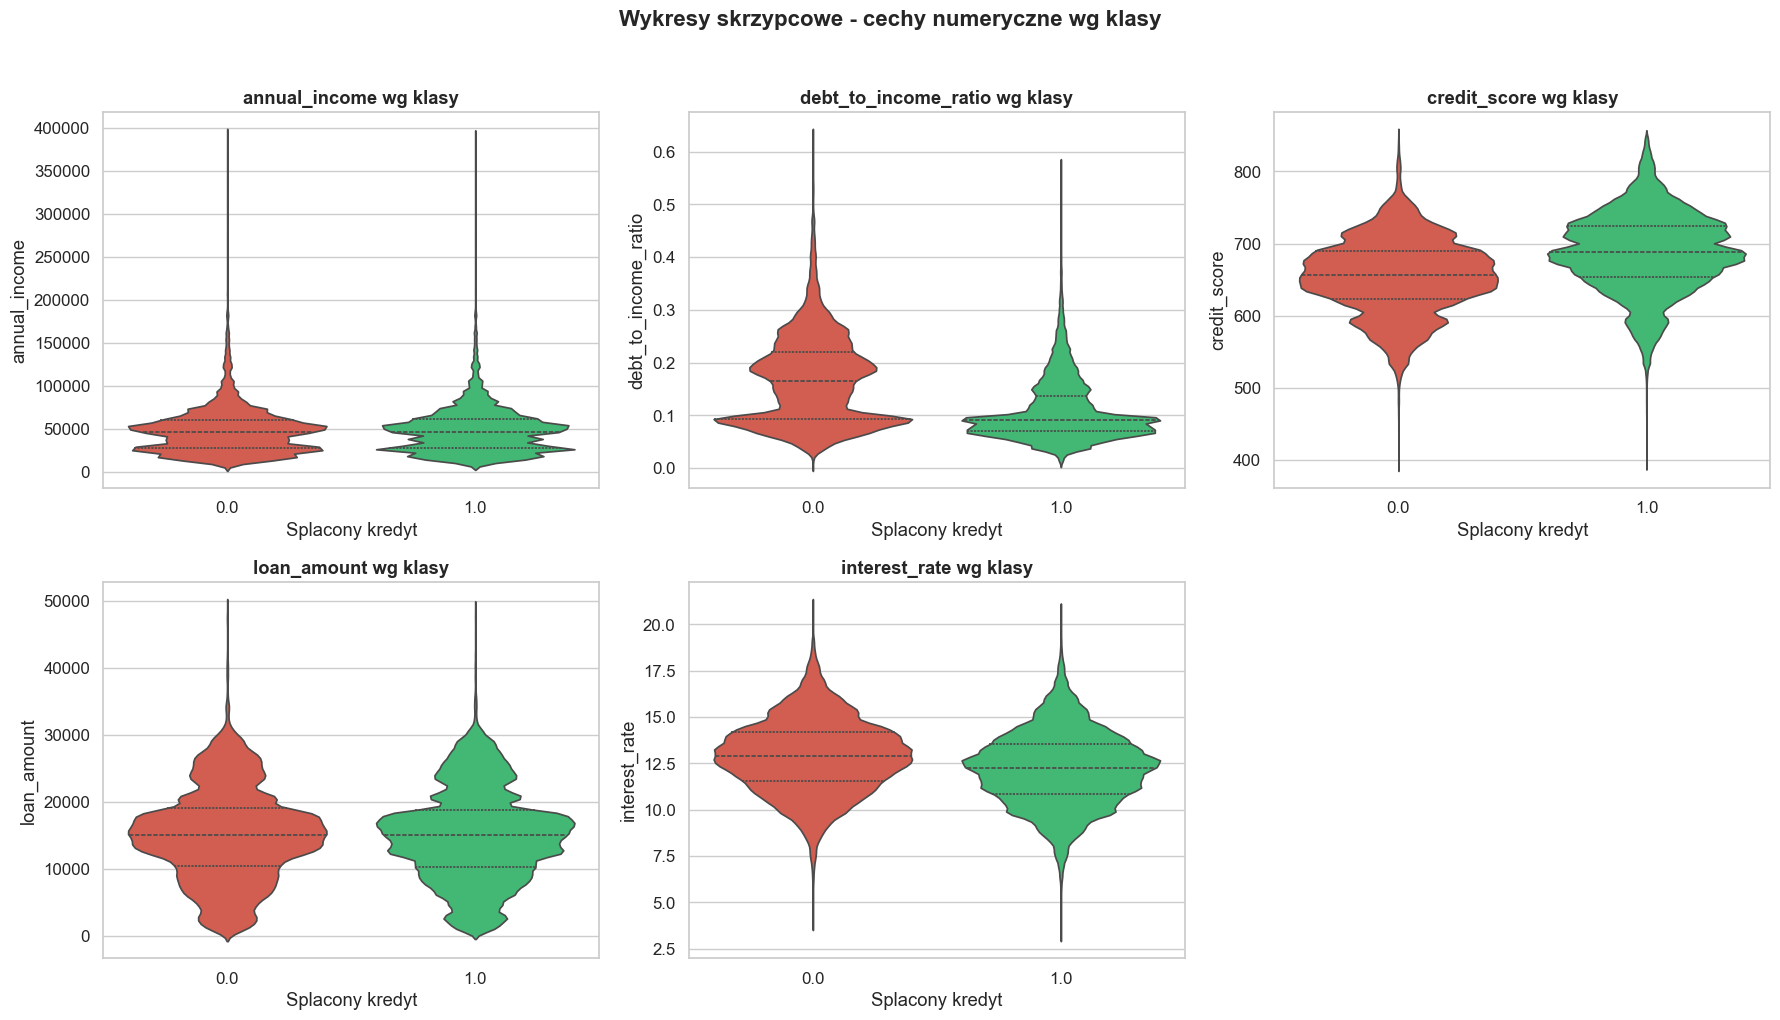

In [17]:
# Wykresy skrzypcowe - pokazuja pelny rozklad z kwartylami
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.violinplot(data=train, x='loan_paid_back', y=col, ax=ax, 
                   palette=['#e74c3c', '#2ecc71'], inner='quartile')
    ax.set_title(f'{col} wg klasy', fontweight='bold')
    ax.set_xlabel('Splacony kredyt')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Wykresy skrzypcowe - cechy numeryczne wg klasy', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Wnioski z wykresów skrzypcowych:

- annual_income - kształty "skrzypiec" dla obu klas są bardzo podobne (zbliżone mediany i kwartyle). Dochód sam w sobie słabo rozróżnia klasy. Jednak klasa 0 (niespłacony) ma nieco szerszą podstawę przy niższych dochodach.
- debt_to_income_ratio - widoczna wyraźna różnica, Klasa niesplacony ma znacznie "grubsze" skrzypce w górnej części (wyższe DTI), a mediana klasy 0 leży wyżej niż klasy 1. To potwierdza, że Debt To income jest najsilniejszym predyktorem numerycznym.
- credit_score - dobra separacja. Skrzypce klasy 1 (spłacony) są przesunięte wyżej - mediana i kwartyle sa powyżej klasy 0. Niższy credit score = wyższe ryzyko niespłacenia.
- loan_amount - praktycznie identyczne kształty i mediany dla obu klas. Kwota kredytu sama w sobie nie rozróżnia spłaconych od niespłaconych.
- interest_rate - widoczna różnica - skrzypce klasy 0 są przesunięte w górę (wyższe oprocentowanie). Ma sens, poniewaz im gorsze warunki tym wieksza szansa ze klient nie splaci kredytu 
---

Podsumowanie: Wykresy skrzypcowe potwierdzają wnioski z histogramów gęstości - debt_to_income_ratio, credit_score i interest_rate najlepiej rozdzielają klasy, natomiast annual_income i loan_amount pojedynczo są słabymi predyktorami.

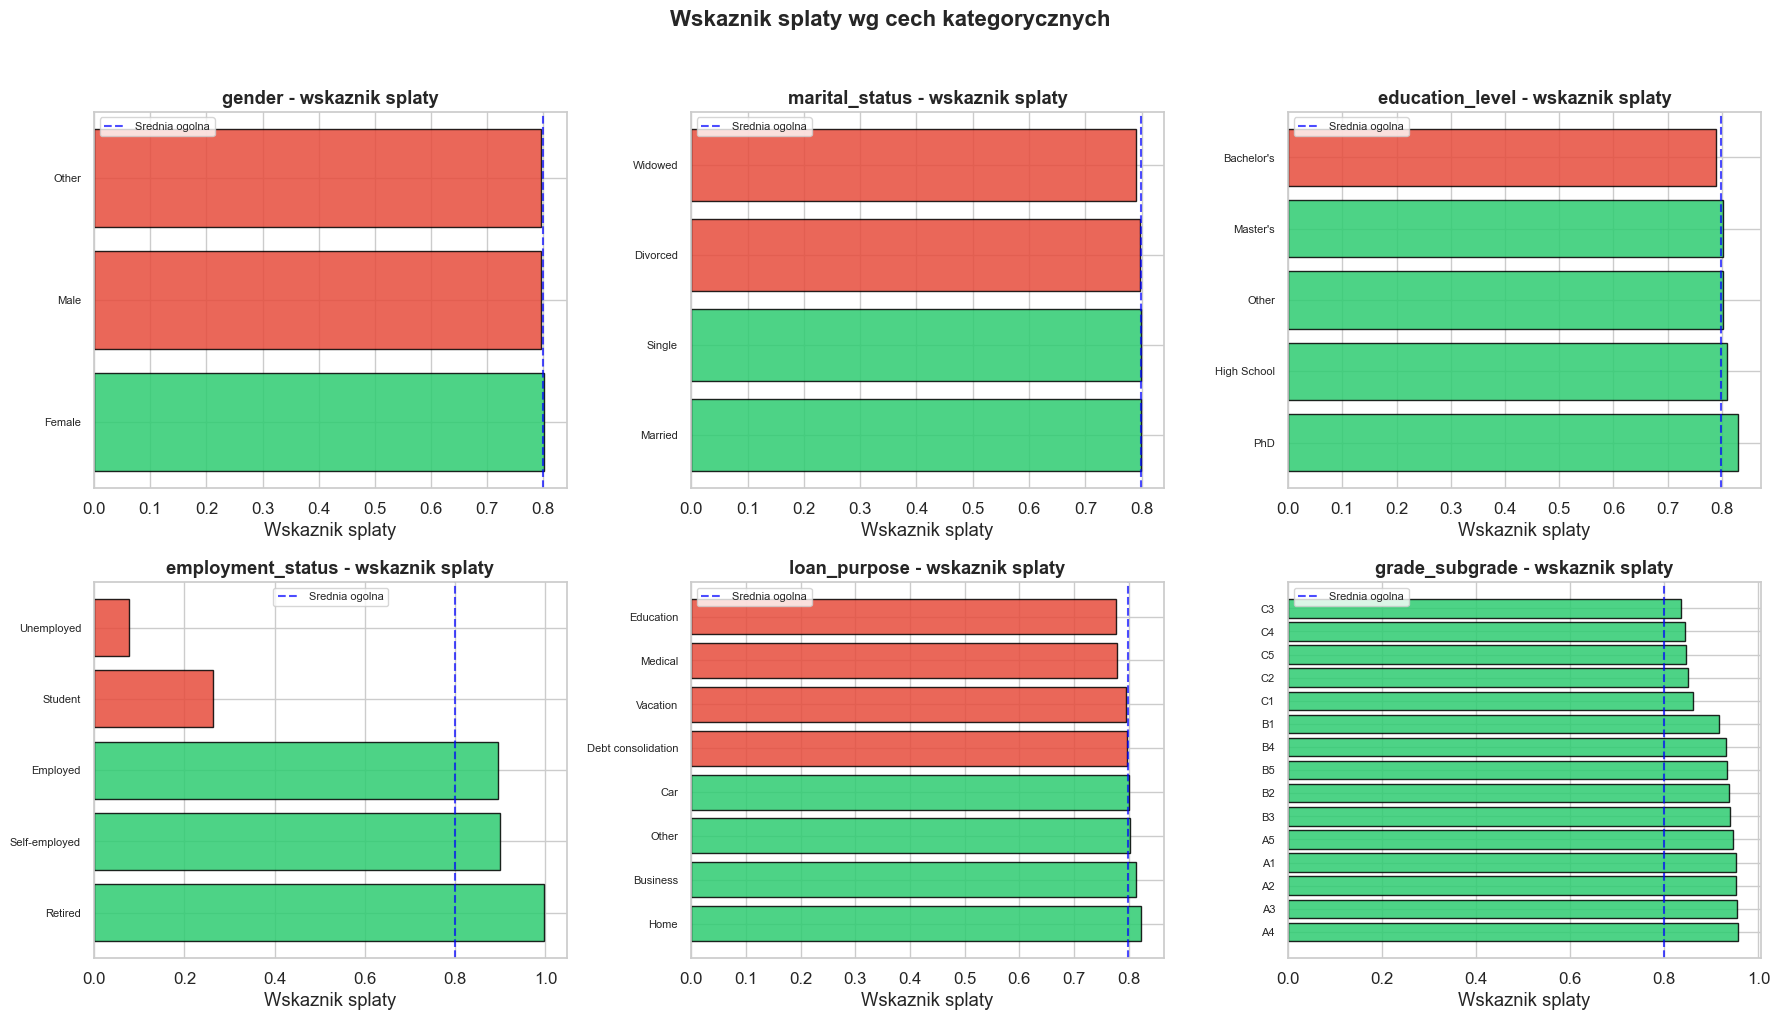

In [18]:
# Wskaznik splaty wg kategorii - to pokazuje sile predykcyjna kazdej cechy kategorycznej
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    repay_rate = train.groupby(col)['loan_paid_back'].mean().sort_values(ascending=False)
    if len(repay_rate) > 15:
        repay_rate = repay_rate.head(15)
    
    colors_bar = ['#2ecc71' if v > train['loan_paid_back'].mean() else '#e74c3c' for v in repay_rate.values]
    ax.barh(range(len(repay_rate)), repay_rate.values, color=colors_bar, edgecolor='black', alpha=0.85)
    ax.set_yticks(range(len(repay_rate)))
    ax.set_yticklabels(repay_rate.index, fontsize=8)
    ax.set_xlabel('Wskaznik splaty')
    ax.set_title(f'{col} - wskaznik splaty', fontweight='bold')
    ax.axvline(train['loan_paid_back'].mean(), color='blue', linestyle='--', alpha=0.7, label='Srednia ogolna')
    ax.legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Wskaznik splaty wg cech kategorycznych', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Wnioski z analizy kategorycznej:**
- **employment_status** - dzieki niemy mozemy bardzo duzo przewidziec! Retired (emeryci) splacaja 99.7%, a bezrobotni tylko 7.8%. To najsilniejsza pojedyncza cecha w zbiorze.
- **education_level**: PhD ma najwyzszy wskaznik (83%), Bachelor's najnizszy (78.9%) - roznica mniejsza niz w employment.
- **loan_purpose**: Home i Business maja lekko wyzszy wskaznik, Medical i Education najnizszy.
- **gender i marital_status**: Malutkie roznice - te cechy sa slabymi predyktorami.

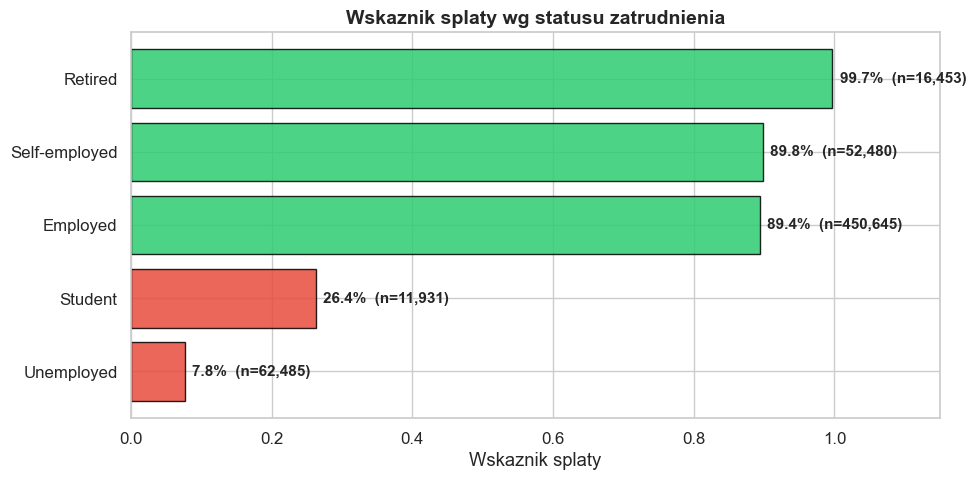

employment_status ma bardzo silna moc predykcyjna
  Emeryt (Retired):    99.7% splaca - praktycznie pewny kredyt
  Zatrudniony:         89.4% splaca
  Samozatrudniony:     89.8% splaca
  Student:             26.4% splaca - wysokie ryzyko niesplaty
  Bezrobotny:          7.8% splaca  - bardzo wysokie ryzyko niesplaty

Decyzja: ordinalna zmienna 'employment_risk' oraz flagi binarne


In [19]:
# Gleboka analiza employment_status
fig, ax = plt.subplots(figsize=(10, 5))
emp_rate = train.groupby('employment_status')['loan_paid_back'].agg(['mean','count']).sort_values('mean', ascending=True)
colors_emp = ['#e74c3c' if v < 0.5 else '#f39c12' if v < 0.85 else '#2ecc71' for v in emp_rate['mean']]

bars = ax.barh(emp_rate.index, emp_rate['mean'], color=colors_emp, edgecolor='black', alpha=0.85)
ax.set_xlabel('Wskaznik splaty')
ax.set_title('Wskaznik splaty wg statusu zatrudnienia', fontweight='bold', fontsize=14)

for i, (rate, count) in enumerate(zip(emp_rate['mean'], emp_rate['count'])):
    ax.text(rate + 0.01, i, f'{rate:.1%}  (n={count:,})', va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, 1.15)
plt.tight_layout()
plt.show()

print("employment_status ma bardzo silna moc predykcyjna")
print("  Emeryt (Retired):    99.7% splaca - praktycznie pewny kredyt")
print("  Zatrudniony:         89.4% splaca")  
print("  Samozatrudniony:     89.8% splaca")
print("  Student:             26.4% splaca - wysokie ryzyko niesplaty")
print("  Bezrobotny:          7.8% splaca  - bardzo wysokie ryzyko niesplaty")
print("\nDecyzja: ordinalna zmienna 'employment_risk' oraz flagi binarne")

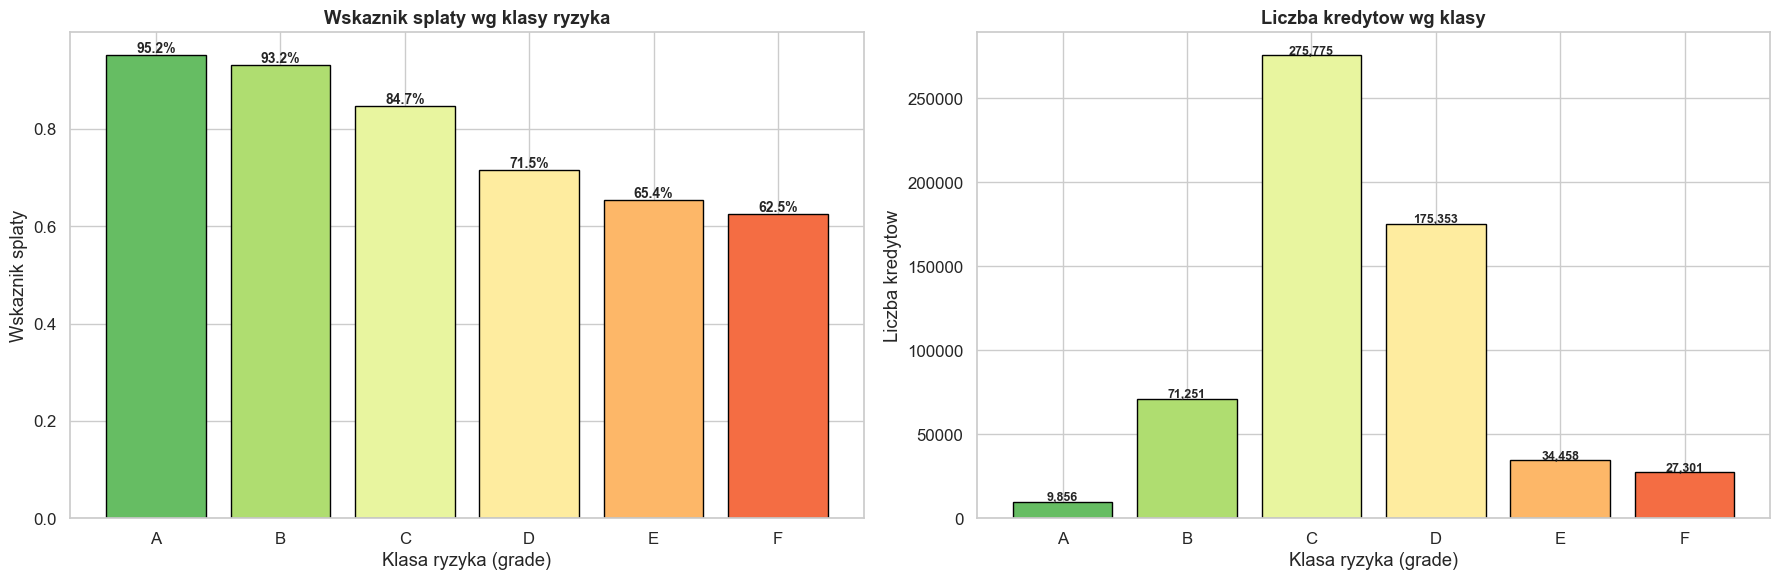

Wniosek: Grade ma spadek od A (95.2%) do F (62.5%)
Klasa C dominuje- wiekszosc kredytow to srednie ryzyko


In [20]:
# Analiza grade - to wbudowany scoring ryzyka
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

grade = train.copy()
grade['grade'] = grade['grade_subgrade'].str[0]
grade_rate = grade.groupby('grade')['loan_paid_back'].agg(['mean', 'count']).sort_index()

colors_grade = plt.cm.RdYlGn(np.linspace(0.8, 0.2, len(grade_rate)))
axes[0].bar(grade_rate.index, grade_rate['mean'], color=colors_grade, edgecolor='black')
axes[0].set_xlabel('Klasa ryzyka (grade)')
axes[0].set_ylabel('Wskaznik splaty')
axes[0].set_title('Wskaznik splaty wg klasy ryzyka', fontweight='bold')
for idx, val in enumerate(grade_rate['mean']):
    axes[0].text(idx, val + 0.005, f'{val:.1%}', ha='center', fontsize=10, fontweight='bold')

axes[1].bar(grade_rate.index, grade_rate['count'], color=colors_grade, edgecolor='black')
axes[1].set_xlabel('Klasa ryzyka (grade)')
axes[1].set_ylabel('Liczba kredytow')
axes[1].set_title('Liczba kredytow wg klasy', fontweight='bold')
for idx, val in enumerate(grade_rate['count']):
    axes[1].text(idx, val + 500, f'{val:,}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("Wniosek: Grade ma spadek od A (95.2%) do F (62.5%)")
print("Klasa C dominuje- wiekszosc kredytow to srednie ryzyko")

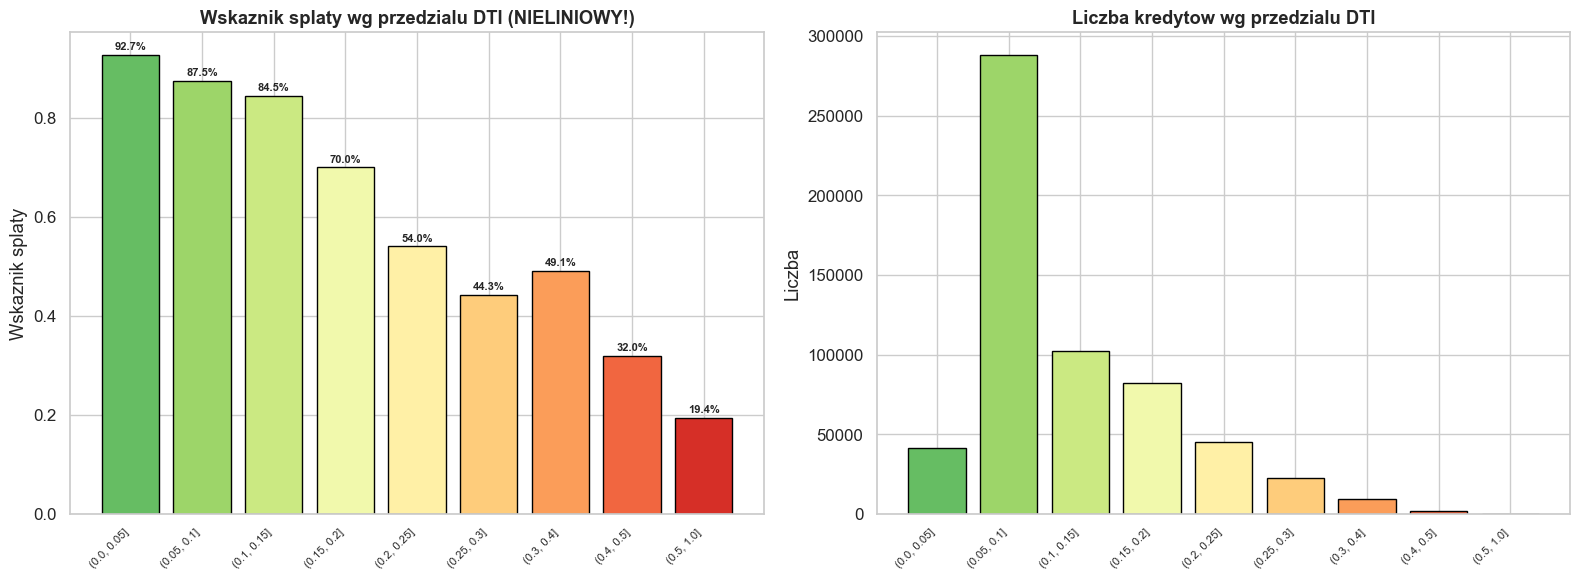

Debt To income ma ostry, NIELINIOWY spadek wskaznika splaty!
  DTI < 0.1:   ~90% splaca
  DTI 0.1-0.2: ~78% splaca
  DTI 0.2-0.3: ~51% splaca, nastepnuje tutaj gwaltowny spadek o ok 27pp
  DTI > 0.3:   ~46% splaca

Decyzja: Dodamy cechy polynomialne (DTI^2, DTI^3) i progi (>0.2, >0.3)


In [21]:
# Analiza nieliniowosci DTI - kluczowa dla feature engineering
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

dti_bins = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 1.0]
train['dti_bucket'] = pd.cut(train['debt_to_income_ratio'], bins=dti_bins)
dti_rate = train.groupby('dti_bucket', observed=True)['loan_paid_back'].agg(['mean','count'])

colors_dti = plt.cm.RdYlGn(np.linspace(0.8, 0.1, len(dti_rate)))
axes[0].bar(range(len(dti_rate)), dti_rate['mean'], color=colors_dti, edgecolor='black')
axes[0].set_xticks(range(len(dti_rate)))
axes[0].set_xticklabels([str(x) for x in dti_rate.index], rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Wskaznik splaty')
axes[0].set_title('Wskaznik splaty wg przedzialu DTI (NIELINIOWY!)', fontweight='bold')
for idx, val in enumerate(dti_rate['mean']):
    axes[0].text(idx, val + 0.01, f'{val:.1%}', ha='center', fontsize=8, fontweight='bold')

axes[1].bar(range(len(dti_rate)), dti_rate['count'], color=colors_dti, edgecolor='black')
axes[1].set_xticks(range(len(dti_rate)))
axes[1].set_xticklabels([str(x) for x in dti_rate.index], rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Liczba')
axes[1].set_title('Liczba kredytow wg przedzialu DTI', fontweight='bold')

plt.tight_layout()
plt.show()

train.drop(columns=['dti_bucket'], inplace=True)

print("Debt To income ma ostry, NIELINIOWY spadek wskaznika splaty!")
print("  DTI < 0.1:   ~90% splaca")
print("  DTI 0.1-0.2: ~78% splaca")
print("  DTI 0.2-0.3: ~51% splaca, nastepnuje tutaj gwaltowny spadek o ok 27pp")
print("  DTI > 0.3:   ~46% splaca")
print("\nDecyzja: Dodamy cechy polynomialne (DTI^2, DTI^3) i progi (>0.2, >0.3)")

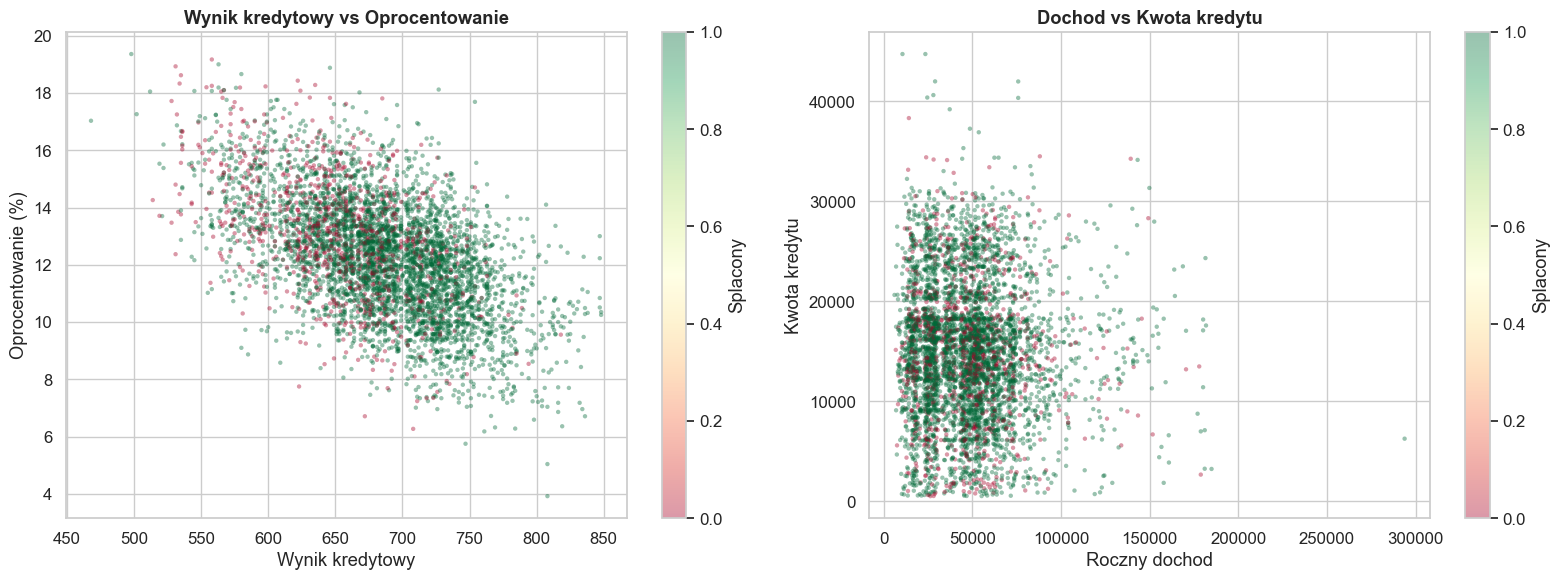

In [22]:
# Wykresy punktowe - szukamy wzorcow w parach cech
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sample = train.sample(5000, random_state=42)
scatter = axes[0].scatter(
    sample['credit_score'], sample['interest_rate'],
    c=sample['loan_paid_back'], cmap='RdYlGn', alpha=0.4, s=10, edgecolor='none'
)
axes[0].set_xlabel('Wynik kredytowy')
axes[0].set_ylabel('Oprocentowanie (%)')
axes[0].set_title('Wynik kredytowy vs Oprocentowanie', fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='Splacony')

scatter2 = axes[1].scatter(
    sample['annual_income'], sample['loan_amount'],
    c=sample['loan_paid_back'], cmap='RdYlGn', alpha=0.4, s=10, edgecolor='none'
)
axes[1].set_xlabel('Roczny dochod')
axes[1].set_ylabel('Kwota kredytu')
axes[1].set_title('Dochod vs Kwota kredytu', fontweight='bold')
plt.colorbar(scatter2, ax=axes[1], label='Splacony')

plt.tight_layout()
plt.show()



Wnioski z wykresow punktowych:
  1. credit_score vs interest_rate: Silna ujemna korelacja (r=-0.54)
     Wyzszy wynik kredytowy -> nizsze oprocentowanie (to logiczne)
  2. income vs loan_amount: Brak wyraznej korelacji
     Ludzie o roznych dochodach biora rozne kwoty
     Ale STOSUNEK tych cech moze byc predykcyjny -> loan_to_income

<a id='7'></a>## 7. Macierz korelacji

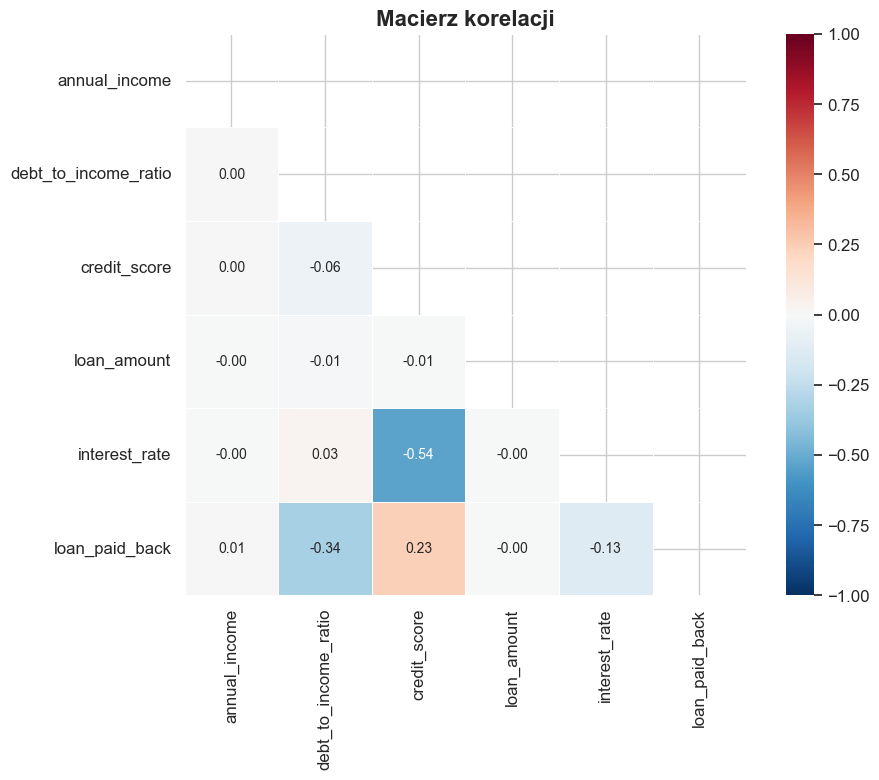

In [23]:
corr_cols = num_cols + ['loan_paid_back']
corr_matrix = train[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1, annot_kws={'size': 10})
ax.set_title('Macierz korelacji', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

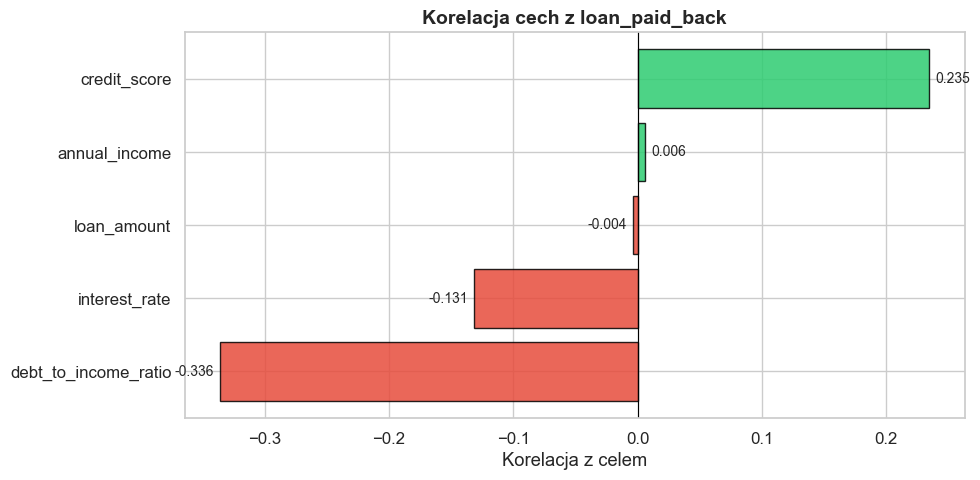

In [24]:
# Korelacja cech z celem - posortowana
target_corr = train[corr_cols].corr()['loan_paid_back'].drop('loan_paid_back').sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors_corr = ['#e74c3c' if v < 0 else '#2ecc71' for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors_corr, edgecolor='black', alpha=0.85)
ax.set_xlabel('Korelacja z celem')
ax.set_title('Korelacja cech z loan_paid_back', fontweight='bold', fontsize=14)
ax.axvline(0, color='black', linewidth=0.8)

for i, v in enumerate(target_corr.values):
    ax.text(v + 0.005 if v >= 0 else v - 0.005, i, f'{v:.3f}', 
            va='center', ha='left' if v >= 0 else 'right', fontsize=10)

plt.tight_layout()
plt.show()

**Wnioski z analizy korelacji:
**- **debt_to_income_ratio -> cel: r = -0.34** - najsilniejszy pojedynczy predyktor numeryczny. Im wyzszy DTI, tym mniejsza szansa na splate.
- **credit_score -> cel: r = +0.23** - wyzszy wynik kredytowy = wieksza splata. Logiczne.
- - **interest_rate -> cel: r = -0.13** - wyzsze oprocentowanie (gorszy profil ryzyka) = mniejsza splata.
- - **credit_score <-> interest_rate: r = -0.54** - SILNA korelacja! To wspolliniowosc. 
- 
- **Decyzja: stworzymy "residual" oprocentowania** (czesc niewyjasniona przez wynik kredytowy), co da modelowi dodatkowa informacje.
- - **annual_income i loan_amount -> cel: r ~ 0** - same w sobie slabe, ale ich stosunek (loan_to_income) jest o wiele silniejszy.

<a id='8'></a>## 8. Wnioski z EDA i decyzje oparte na danych

**employment_status**: Emeryt=99.7%, Bezrobotny=7.8% - przepasc 92pp   Tworzymy ordinalna zmienna ryzyka + flagi binarne dla ekstremalnych grup 

**debt_to_income_ratio**: Ostry nieliniowy klif przy 0.2 (90% -> 51%)   Dodajemy cechy polynomialne (DTI^2, DTI^3) + flagi progowe przy 0.2 i 0.3 

**annual_income**: Skosnosc=1.72, 2.68% outlierow   Obcinamy na 99. percentylu (~142k) + flaga outliera + transformacja sqrt 

**credit_score vs interest_rate**: r = -0.54   Tworzymy residual oprocentowania 

**loan_amount / income** pojedynczo ~0 korelacji, ale stosunki dzialaja   Dodajemy wiecej cech interakcyjnych i stosunkow 

**Grade A->F**: Monotoniczny spadek splaty 95.2% -> 62.5%   Mamy juz kodowanie ordinalne; dodajemy interakcje grade x DTI 

**Dysbalans klas**: Proporcja 80/20   Uzywamy StratifiedKFold; drzewa radza sobie z takim niebalansem 

**Rozklady train/test**: Prawie identyczne srednie i odchylenia
